<a href="https://colab.research.google.com/github/mchlgho22/Project3_SelfDrivingCar_DeepLabV3Plus/blob/main/SelfDriving_DeepLabV3%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [ ]:
# ================================
# Setup & Import
# ================================
import os, glob, cv2, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from collections import Counter

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ================================
# Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !unzip "/content/drive/MyDrive/SelfDrivingCar/dataset.zip" -d "/content/drive/MyDrive/SelfDrivingCar/"

In [ ]:
# =========================================
# PATH
# =========================================
BASE_DIR = "/content/drive/MyDrive/SelfDrivingCar"
IMG_DIR = f"{BASE_DIR}/dataset/images_prepped_train"
MASK_DIR = f"{BASE_DIR}/dataset/annotations_prepped_train"

In [ ]:
# =========================================
# LOAD DATASET
# =========================================
image_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))

pairs = []
for img_path in image_paths:
    mask_path = os.path.join(MASK_DIR, os.path.basename(img_path))
    if os.path.exists(mask_path):
        pairs.append((img_path, mask_path))

print("Total dataset:", len(pairs))

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

Total dataset: 367


In [ ]:
# ================================
# CLASS MAP
# ================================
all_classes = set()
for _, m in pairs:
    mask = cv2.imread(m, 0)
    all_classes.update(np.unique(mask))

all_classes = sorted(list(all_classes))
CLASS_MAP = {v: i for i, v in enumerate(all_classes)}
NUM_CLASSES = len(CLASS_MAP)

print("CLASS MAP:", CLASS_MAP)

def encode_mask(mask):
    out = np.zeros_like(mask)
    for k, v in CLASS_MAP.items():
        out[mask == k] = v
    return out

CLASS MAP: {np.uint8(0): 0, np.uint8(1): 1, np.uint8(2): 2, np.uint8(3): 3, np.uint8(4): 4, np.uint8(5): 5, np.uint8(6): 6, np.uint8(7): 7, np.uint8(8): 8, np.uint8(9): 9, np.uint8(10): 10, np.uint8(11): 11}


In [ ]:
# ================================
# CLASS WEIGHT
# ================================
pixel_count = np.zeros(NUM_CLASSES)

for _, m in train_pairs:
    mask = encode_mask(cv2.imread(m, 0))
    for c in range(NUM_CLASSES):
        pixel_count[c] += np.sum(mask == c)

pixel_count = np.clip(pixel_count, 1, None)

class_weights = 1.0 / np.sqrt(pixel_count)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights).float().to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.3542, 0.3010, 1.4500, 0.2578, 0.6867, 0.4712, 1.3382, 1.3352, 0.6058,
        1.8394, 2.6297, 0.7309], device='cuda:0')


In [ ]:
# ================================
# CLASS-AWARE CROP
# ================================
class ClassAwareCrop:
    def __init__(self, size=512, rare_classes=[2,9,10], min_pixels=300):
        self.size = size
        self.rare_classes = rare_classes
        self.min_pixels = min_pixels

    def __call__(self, image, mask):
        h, w = mask.shape

        if h < self.size or w < self.size:
            return {
                "image": cv2.resize(image,(512,512)),
                "mask": cv2.resize(mask,(512,512),interpolation=cv2.INTER_NEAREST)
            }

        for _ in range(10):
            y = np.random.randint(0, h - self.size)
            x = np.random.randint(0, w - self.size)

            crop_mask = mask[y:y+self.size, x:x+self.size]

            for c in self.rare_classes:
                if np.sum(crop_mask == c) > self.min_pixels:
                    return {
                        "image": image[y:y+self.size, x:x+self.size],
                        "mask": crop_mask
                    }

        y = np.random.randint(0, h - self.size)
        x = np.random.randint(0, w - self.size)

        return {
            "image": image[y:y+self.size, x:x+self.size],
            "mask": mask[y:y+self.size, x:x+self.size]
        }

class_crop = ClassAwareCrop()

In [ ]:
# ================================
# AUGMENTATION
# ================================
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomResizedCrop(size=(512, 512), scale=(0.7, 1.0), p=0.5),
    A.MotionBlur(p=0.2),
    A.GaussNoise(p=0.2),
    A.RandomBrightnessContrast(p=0.5),
])

val_aug = A.Compose([
    A.Resize(512,512)
])

norm = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [ ]:
# ================================
# DATASET
# ================================
class SegDataset(Dataset):
    def __init__(self, pairs, train=True):
        self.pairs = pairs
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = encode_mask(cv2.imread(mask_path, 0))

        if self.train:
            out = class_crop(img, mask)
            img, mask = out["image"], out["mask"]

            out = train_aug(image=img, mask=mask)
            img, mask = out["image"], out["mask"]
        else:
            out = val_aug(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        out = norm(image=img, mask=mask)
        return out["image"], out["mask"].long()

train_dataset = SegDataset(train_pairs, True)
val_dataset   = SegDataset(val_pairs, False)

In [ ]:
# ================================
# SAMPLER
# ================================
sample_weights = []

for _, m in train_pairs:
    mask = encode_mask(cv2.imread(m, 0))
    unique = np.unique(mask)
    weight = sum(class_weights[c].item() for c in unique)
    sample_weights.append(weight)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


In [ ]:
# ================================
# MODEL (DEEPLABV3+)
# ================================
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
# ================================
# LOSS
# ================================
ce_loss   = torch.nn.CrossEntropyLoss(weight=class_weights)
dice_loss = smp.losses.DiceLoss(mode="multiclass")
focal     = smp.losses.FocalLoss(mode="multiclass")

def loss_fn(pred, target):
    return 0.4*ce_loss(pred,target) + \
           0.3*dice_loss(pred,target) + \
           0.3*focal(pred,target)

In [ ]:
# ================================
# OPTIMIZER + SCHEDULER
# ================================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.3
)

In [ ]:
# ================================
# IoU
# ================================
def compute_iou(pred, mask):
    pred = torch.argmax(pred, dim=1)

    ious = []
    for cls in range(NUM_CLASSES):
        p = (pred == cls)
        m = (mask == cls)

        inter = (p & m).sum().item()
        union = (p | m).sum().item()

        if union == 0:
            continue

        ious.append(inter / union)

    return np.mean(ious) if len(ious) > 0 else 0

In [ ]:
# ================================
# TRAIN LOOP
# ================================
EPOCHS = 10
best_iou = 0
patience = 2
no_improve = 0

history = {"train_loss": [], "val_loss": [], "iou": []}

epoch_times = []

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
use_amp = torch.cuda.is_available()

os.makedirs(f"{BASE_DIR}/model", exist_ok=True)

for epoch in range(EPOCHS):
    start = time.time()

    # TRAIN
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            preds = model(imgs)
            loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    ious = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            with torch.autocast(device_type="cuda", enabled=use_amp):
                preds = model(imgs)
                loss = loss_fn(preds, masks)

            val_loss += loss.item()
            ious.append(compute_iou(pred=preds, mask=masks))

    avg_val_loss = val_loss / len(val_loader)
    avg_iou = float(np.mean(ious)) if len(ious) > 0 else 0.0

    scheduler.step(avg_val_loss)

    # SAVE BEST MODEL
    if avg_iou > best_iou:
        best_iou = avg_iou
        no_improve = 0
        torch.save(model.state_dict(), f"{BASE_DIR}/model/deeplabv3plus_best.pth")
    else:
        no_improve += 1

    # EARLY STOPPING
    if no_improve >= patience:
        print("Early stopping triggered")
        break

    # =====================
    # TIME TRACKING
    # =====================
    epoch_time = time.time() - start
    epoch_times.append(epoch_time)

    # HISTORY SAVE
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["iou"].append(avg_iou)

    print(
        f"Epoch {epoch+1} | "
        f"Train {avg_train_loss:.4f} | "
        f"Val {avg_val_loss:.4f} | "
        f"IoU {avg_iou:.4f} | "
        f"Time {time.time()-start:.1f}s"
    )

/tmp/ipykernel_6362/812645976.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Epoch 1 | Train 0.6827 | Val 0.5572 | IoU 0.5212 | Time 17.4s
Epoch 2 | Train 0.6103 | Val 0.5016 | IoU 0.5323 | Time 20.9s
Epoch 3 | Train 0.5539 | Val 0.4572 | IoU 0.5658 | Time 20.0s
Epoch 4 | Train 0.5172 | Val 0.4261 | IoU 0.5745 | Time 19.1s
Epoch 5 | Train 0.4810 | Val 0.4062 | IoU 0.5855 | Time 22.8s
Epoch 6 | Train 0.4524 | Val 0.3917 | IoU 0.5897 | Time 21.1s
Epoch 7 | Train 0.4449 | Val 0.3819 | IoU 0.5914 | Time 22.7s
Epoch 8 | Train 0.4194 | Val 0.3711 | IoU 0.5960 | Time 21.8s
Epoch 9 | Train 0.4110 | Val 0.3528 | IoU 0.6126 | Time 22.3s
Epoch 10 | Train 0.3913 | Val 0.3410 | IoU 0.6209 | Time 21.0s


In [ ]:
# ================================
# SUMMARY
# ================================
print("\n===== TRAINING SUMMARY =====")
print(f"Best IoU       : {best_iou:.4f}")
print(f"Avg epoch time : {np.mean(epoch_times):.2f} sec")
print(f"Total time     : {np.sum(epoch_times):.2f} sec")


===== TRAINING SUMMARY =====
Best IoU       : 0.6209
Avg epoch time : 20.92 sec
Total time     : 209.16 sec


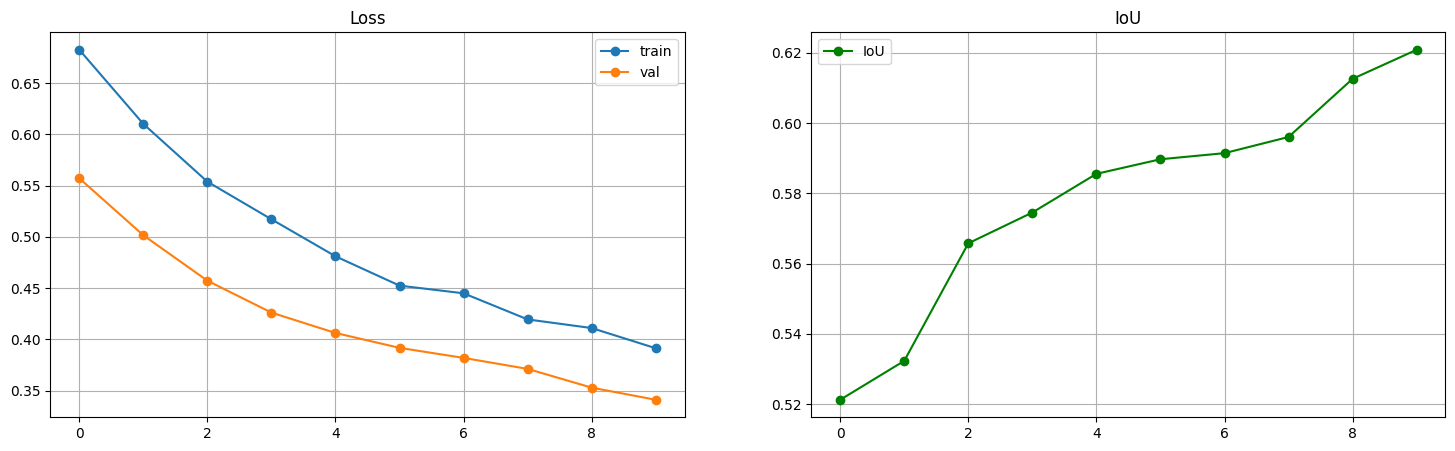

In [ ]:
# ================================
# PLOT
# ================================
plt.figure(figsize=(18,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], marker='o', label="train")
plt.plot(history["val_loss"], marker='o', label="val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history["iou"], label="IoU", marker='o', color="green")
plt.title("IoU")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =========================================
# PER-CLASS IoU + BAR CHART
# =========================================
def per_class_iou(model, loader):
    model.eval()

    inter = np.zeros(NUM_CLASSES)
    union = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = torch.argmax(model(imgs), dim=1)

            for cls in range(NUM_CLASSES):
                p = preds == cls
                t = masks == cls

                inter[cls] += (p & t).sum().item()
                union[cls] += (p | t).sum().item()

    iou = inter / (union + 1e-6)

    # PRINT
    print("=== Per-Class IoU ===")
    for i, val in enumerate(iou):
        print(f"Class {i}: {val:.4f}")

    print("Mean IoU:", np.mean(iou))

    # BAR CHART
    plt.figure(figsize=(10,4))
    plt.bar(range(NUM_CLASSES), iou)
    plt.title("Per-Class IoU")
    plt.xlabel("Class")
    plt.ylabel("IoU")
    plt.grid()
    plt.show()

    return iou

=== Per-Class IoU ===
Class 0: 0.9115
Class 1: 0.8620
Class 2: 0.1867
Class 3: 0.9610
Class 4: 0.7580
Class 5: 0.7839
Class 6: 0.4573
Class 7: 0.6446
Class 8: 0.8362
Class 9: 0.3656
Class 10: 0.4207
Class 11: 0.4623
Mean IoU: 0.637487427625938


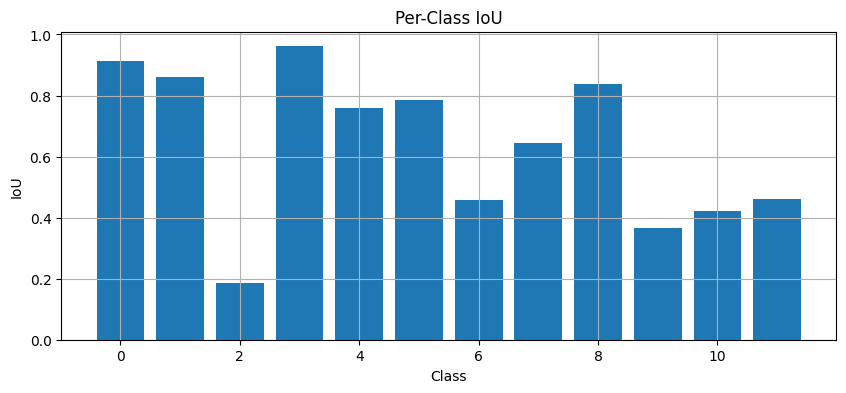

In [ ]:
iou_scores = per_class_iou(model, val_loader)

In [ ]:
# =========================================
# CONFUSION MATRIX
# =========================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)

            preds = torch.argmax(model(imgs), dim=1).cpu().numpy()
            masks = masks.numpy()

            all_preds.extend(preds.flatten())
            all_targets.extend(masks.flatten())

    cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return cm

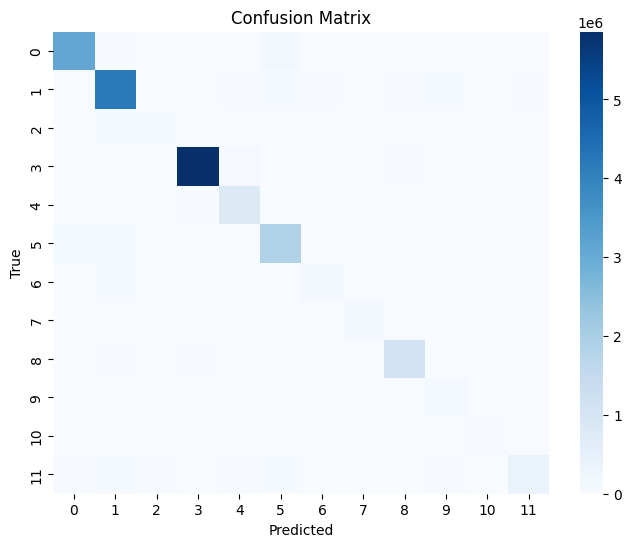

In [ ]:
cm = plot_confusion_matrix(model, val_loader)

In [ ]:
# =========================================
# ERROR ANALYSIS
# =========================================
def analyze_errors(cm):
    print("=== TOP CONFUSIONS ===")

    for i in range(NUM_CLASSES):
        row = cm[i].copy()
        row[i] = 0  # ignore correct

        if row.sum() == 0:
            continue

        top_confused = np.argmax(row)
        print(f"Class {i} paling sering salah jadi Class {top_confused}")

In [ ]:
analyze_errors(cm)

=== TOP CONFUSIONS ===
Class 0 paling sering salah jadi Class 5
Class 1 paling sering salah jadi Class 9
Class 2 paling sering salah jadi Class 1
Class 3 paling sering salah jadi Class 4
Class 4 paling sering salah jadi Class 3
Class 5 paling sering salah jadi Class 1
Class 6 paling sering salah jadi Class 1
Class 7 paling sering salah jadi Class 1
Class 8 paling sering salah jadi Class 1
Class 9 paling sering salah jadi Class 1
Class 10 paling sering salah jadi Class 11
Class 11 paling sering salah jadi Class 1


In [ ]:
# ================================
# LOAD MODEL
# ================================
import torch
import segmentation_models_pytorch as smp

MODEL_PATH = "/content/drive/MyDrive/SelfDrivingCar/model/deeplabv3plus_best.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# LOAD CHECKPOINT
# ================================
checkpoint = torch.load(MODEL_PATH, map_location=device)

# ================================
# MODEL (HARUS SAMA DENGAN TRAINING)
# ================================
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    classes=NUM_CLASSES  # ⚠️ HARUS SAMA DENGAN TRAINING
).to(device)

# ================================
# HANDLE DataParallel PREFIX
# ================================
new_state_dict = {}
for k, v in checkpoint.items():
    if k.startswith("module."):
        new_state_dict[k[7:]] = v
    else:
        new_state_dict[k] = v

# ================================
# LOAD WEIGHTS
# ================================
model.load_state_dict(new_state_dict)  # ❌ jangan strict=False kalau bisa

model.eval()

print("✅ Model loaded successfully")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# COLOR MAP
# =========================================
cmap = plt.get_cmap("tab20")

def colorize_mask(mask):
    mask = mask.cpu().numpy()
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.float32)

    for i in range(NUM_CLASSES):
        color[mask == i] = cmap(i % 20)[:3]  # 🔥 safe modulo

    return color

# =========================================
# DENORMALIZE FUNCTION
# =========================================
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.permute(1,2,0).cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

# =========================================
# OVERLAY FIX
# =========================================
def overlay(img, mask_color, alpha=0.5):
    # 🔥 boost visibility
    mask_color = np.clip(mask_color * 1.2, 0, 1)
    return img * (1 - alpha) + mask_color * alpha

# =========================================
# VISUALISASI
# =========================================
import random
import torch
import matplotlib.pyplot as plt

def visualize(model, dataset, idx=None):
    model.eval()

    if idx is None:
        idx = random.randint(0, len(dataset)-1)

    img, mask = dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(pred, dim=1).squeeze().cpu()

    img_vis = denormalize(img)

    mask_color = colorize_mask(mask)
    pred_color = colorize_mask(pred)

    overlay_img = overlay(img_vis, pred_color)

    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.imshow(img_vis)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(mask_color)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pred_color)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(overlay_img)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

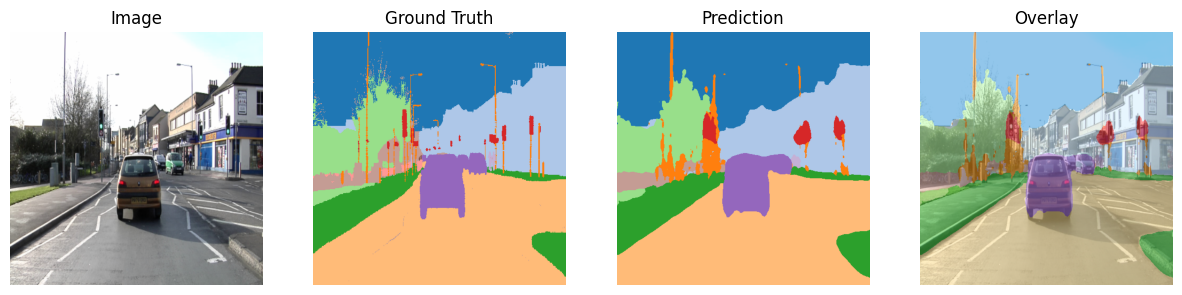

In [ ]:
# visualize(model, dataset)
visualize(model, val_dataset, idx=0)

In [ ]:
# ================================
# SETUP UPLOAD
# ================================
from google.colab import files
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
# ================================
# UPLOAD IMAGE
# ================================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving cross.png to cross.png


In [ ]:
# ================================
# Preprocess + inference
# ================================
def predict_image(model, img_path):
    model.eval()

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    orig = img.copy()

    # resize
    img_resized = cv2.resize(img, (512, 512))

    # normalize
    img_tensor = norm(image=img_resized)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # resize pred ke original
    pred = cv2.resize(pred.astype(np.uint8), (orig.shape[1], orig.shape[0]))

    return orig, pred

In [ ]:
# ================================
# Visualisasi
# ================================
def show_result(orig, pred):
    mask_color = colorize_mask(torch.tensor(pred))

    overlay_img = (orig / 255.0) * 0.5 + mask_color * 0.5

    plt.figure(figsize=(15, 5))

    plt.subplot(1,3,1)
    plt.imshow(orig)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask_color)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay_img)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

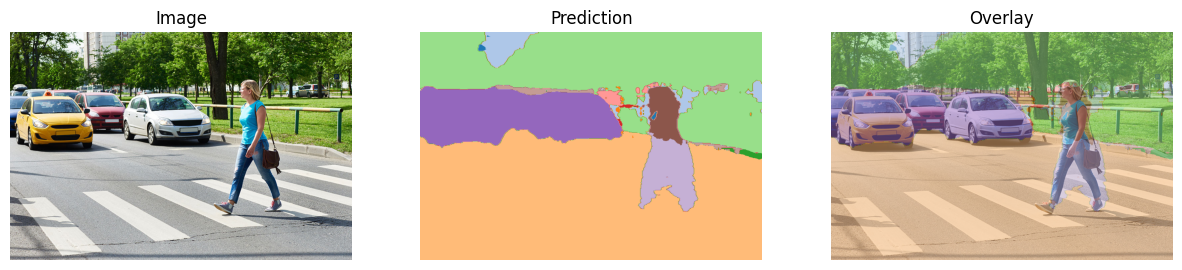

In [ ]:
# ================================
# RUN IMAGE
# ================================
orig, pred = predict_image(model, img_path)
show_result(orig, pred)

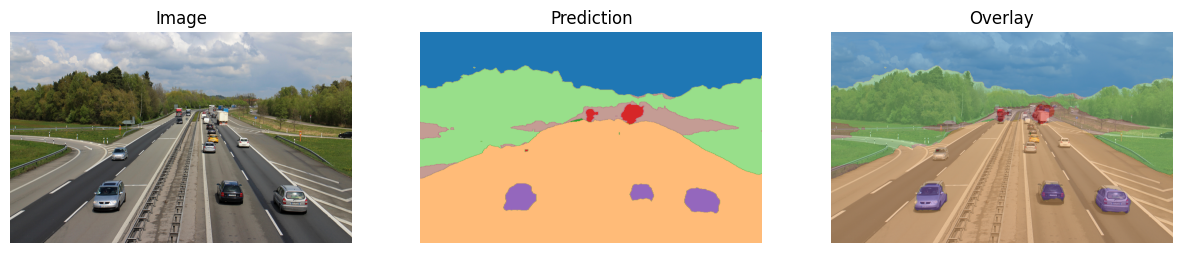

In [ ]:
# ================================
# RUN IMAGE
# ================================
orig, pred = predict_image(model, img_path)
show_result(orig, pred)

In [ ]:
# ================================
# UPLOAD VIDEO
# ================================
from google.colab import files

uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("Uploaded:", video_path)

Saving video_jalan.mp4 to video_jalan.mp4
Uploaded: video_jalan.mp4


In [ ]:
# ================================
# LOAD MODEL
# ================================
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

model.load_state_dict(torch.load(f"{BASE_DIR}/model/deeplabv3plus_best.pth"))
model.eval()

In [ ]:
# ================================
# COLOR MAP
# ================================
def get_colormap(n):
    np.random.seed(42)
    return np.random.randint(0,255,(n,3))

COLORS = get_colormap(NUM_CLASSES)

In [ ]:
# ================================
# INFERENCE VIDEO
# ================================
import cv2

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = "output_deeplabv3plus.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, fps, (w,h))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (512,512))

    x = img_resized / 255.0
    x = (x - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
    x = torch.tensor(x).permute(2,0,1).float().unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x)
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # resize kembali ke original
    pred = cv2.resize(pred.astype(np.uint8), (w,h), interpolation=cv2.INTER_NEAREST)

    # colorize mask
    color_mask = COLORS[pred]

    # overlay
    overlay = cv2.addWeighted(frame, 0.7, color_mask.astype(np.uint8), 0.3, 0)

    out.write(overlay)

cap.release()
out.release()

print("Saved:", out_path)

Saved: output_deeplabv3plus.mp4


In [ ]:
# ================================
# DOWNLOAD VIDEO
# ================================
from google.colab import files
files.download("output_deeplabv3plus.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>